<a href="https://colab.research.google.com/github/harmanbajwa2954/Machine-Learning-Notebooks/blob/main/Type_of_Brain_Tumor_EfficientnetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Type of Brain Tumor Detection using MRI images**

USING EfficientNETB0

## Importing Libraries and Tools

In [1]:
!git clone https://github.com/harmanbajwa2954/MRI_Brain_Tumor_Detection.git

Cloning into 'MRI_Brain_Tumor_Detection'...
remote: Enumerating objects: 7280, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 7280 (delta 22), reused 35 (delta 3), pack-reused 7211 (from 3)
Receiving objects: 100% (7280/7280), 155.66 MiB | 18.96 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Updating files: 100% (7501/7501), done.
Filtering content: 100% (2/2), 244.47 MiB | 4.35 MiB/s, done.


In [2]:
!pip install tensorflow


In [3]:

import os #for directory and file operations
import numpy as np
import random
from PIL import Image, ImageEnhance # Pillow library used to work with images
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

#keras
from keras.applications import EfficientNetB0
from keras.applications.efficientnet import preprocess_input
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization,Flatten, Input
from keras.models import Model
from keras.models import Sequential  #for building the model
from keras.preprocessing.image import load_img
from keras.optimizers import Adam    #for optimization
from keras.callbacks import ReduceLROnPlateau

from sklearn.utils import shuffle # for shuffling the data

In [4]:
!python --version

Python 3.12.13


## Load Datasets

In [5]:
# Directories for training and testing data
train_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Training/'
test_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/'

#laod and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

#load and shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

In [25]:
# Checking for class imbalance
from collections import Counter
print(Counter(train_labels))

Counter({'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400})


## Data Visualization

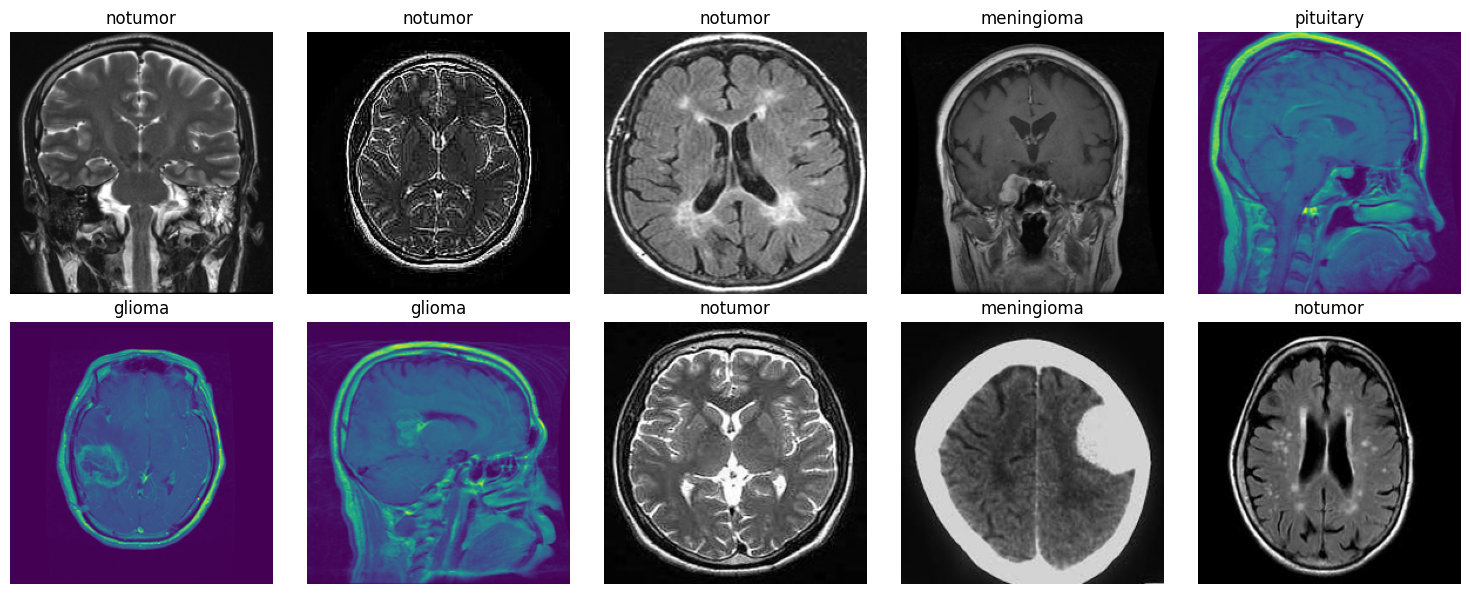

In [6]:
#selecting random incies for 10 images
random_indices = random.sample(range(len(train_paths)),10)

#Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((224,224))

  #Display images inside the loop
  axes[i].imshow(img)
  axes[i].set_title(train_labels[idx]) # Add title with label
  axes[i].axis("off")

plt.tight_layout()
plt.show()

## Image Preprocessing (Helper Functions)

In [7]:
from numpy._core.defchararray import encode
#image augmentation fucntion
def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Sharpness(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)
  image = preprocess_input(image)
  if random.random() > 0.5:
    image = np.fliplr(image)

  if random.random() > 0.5:
    image = np.flipud(image)


  # slight rotation
  angle = random.uniform(-15, 15)
  image = Image.fromarray(image.astype('uint8')).rotate(angle)
  image = np.array(image)

  return image

#Load images and apply augmentation
def open_images(path):
  image = []
  for img_path in path:
    img = load_img(img_path, target_size=(224,224))
    img = np.array(img)
    img = augment_image(img)
    image.append(img)

  return np.array(image)


#Encoder labels : converts label names to integers
def encode_label(labels_to_encode):
  unique_labels = sorted(os.listdir(train_dir)) # Ensure consistent order
  encoded_labels = [unique_labels.index(label) for label in labels_to_encode]
  return np.array(encoded_labels) # Return as a numpy array

# Data generator for batching
def datagen(paths, labels, batch_size=12):
    while True:
        combined = list(zip(paths, labels))
        random.shuffle(combined)
        paths, labels = zip(*combined)

        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i+batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

## **Training Base Model**

Here for this project we are going to use **EfficientnetB0** for Transfer Learning.

> **EfficientnetB0** is a pre-trained convolutional neural network (CNN) for image classification.

> In this part the model will be trained on only few layers rest will be freezed

In [8]:
# Model architecture
IMAGE_SIZE = 224
base_model = EfficientNetB0(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
    )

# Freeze all layers of the EfficentnetB0 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the EfficentnetB0 base model to be trainable
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Build the final model
# Build custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(os.listdir(train_dir)), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 15

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size),
                    steps_per_epoch=steps,
                    epochs=epochs,
                    callbacks=[lr_scheduler])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 72s 108ms/step - loss: 0.9615 - sparse_categorical_accuracy: 0.6230 - learning_rate: 1.0000e-04
Epoch 2/15
  2/280 ━━━━━━━━━━━━━━━━━━━━ 29s 106ms/step - loss: 1.0450 - sparse_categorical_accuracy: 0.7250

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 117ms/step - loss: 0.5467 - sparse_categorical_accuracy: 0.7934 - learning_rate: 1.0000e-04
Epoch 3/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - loss: 0.4193 - sparse_categorical_accuracy: 0.8409 - learning_rate: 1.0000e-04
Epoch 4/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 108ms/step - loss: 0.3547 - sparse_categorical_accuracy: 0.8645 - learning_rate: 1.0000e-04
Epoch 5/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 31s 110ms/step - loss: 0.2985 - sparse_categorical_accuracy: 0.8882 - learning_rate: 1.0000e-04
Epoch 6/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - loss: 0.2772 - sparse_categorical_accuracy: 0.8970 - learning_rate: 1.0000e-04
Epoch 7/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - loss: 0.2450 - sparse_categorical_accuracy: 0.9111 - learning_rate: 1.0000e-04
Epoch 8/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 107ms/step - loss: 0.2147 - sparse_categorical_accuracy: 0.9182 - learning_rate: 1.0000e-04
Epoch 9/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 108ms/step - lo

## Train and Vals

<function matplotlib.pyplot.show(close=None, block=None)>

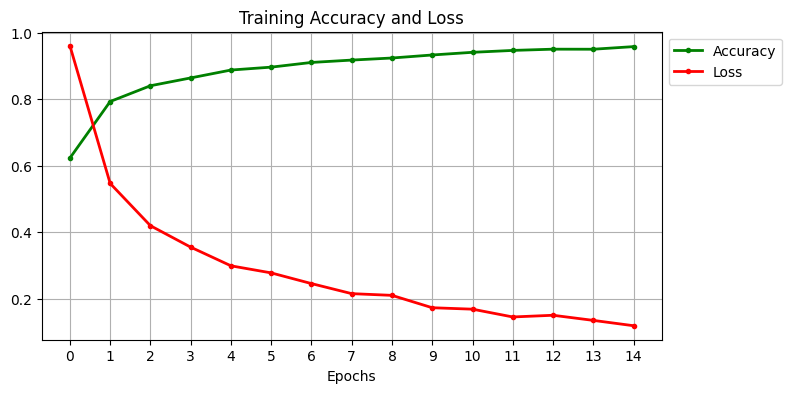

In [9]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2, label='Training Accuracy')
plt.plot(history.history['loss'],'.r-', linewidth=2)
plt.title('Training Accuracy and Loss')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy','Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show

### Classification Report

In [10]:
test_images = open_images(test_paths)
test_label_encoded = encode_label(test_labels)

y_pred = model.predict(test_images)

print('Classification Report:')
print(classification_report(test_label_encoded, np.argmax(y_pred, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87       400
           1       0.88      0.97      0.92       400
           2       0.93      1.00      0.96       400
           3       0.98      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



### Confusion Matrix

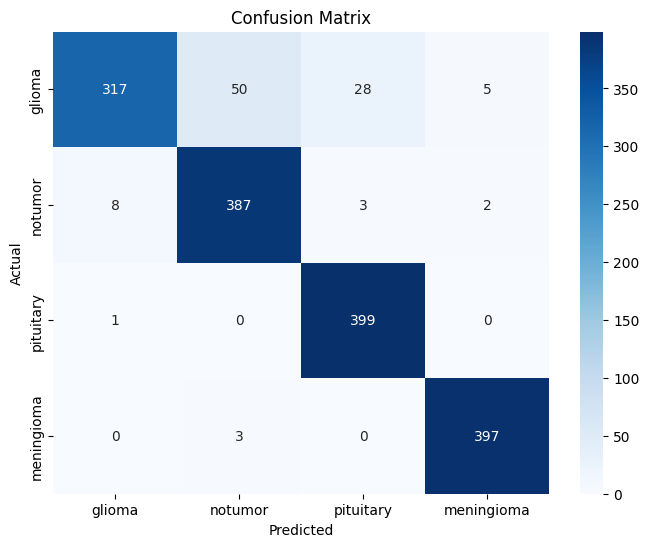

In [11]:
conf_matrix = confusion_matrix(test_label_encoded, np.argmax(y_pred, axis=1))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC and AUC curve

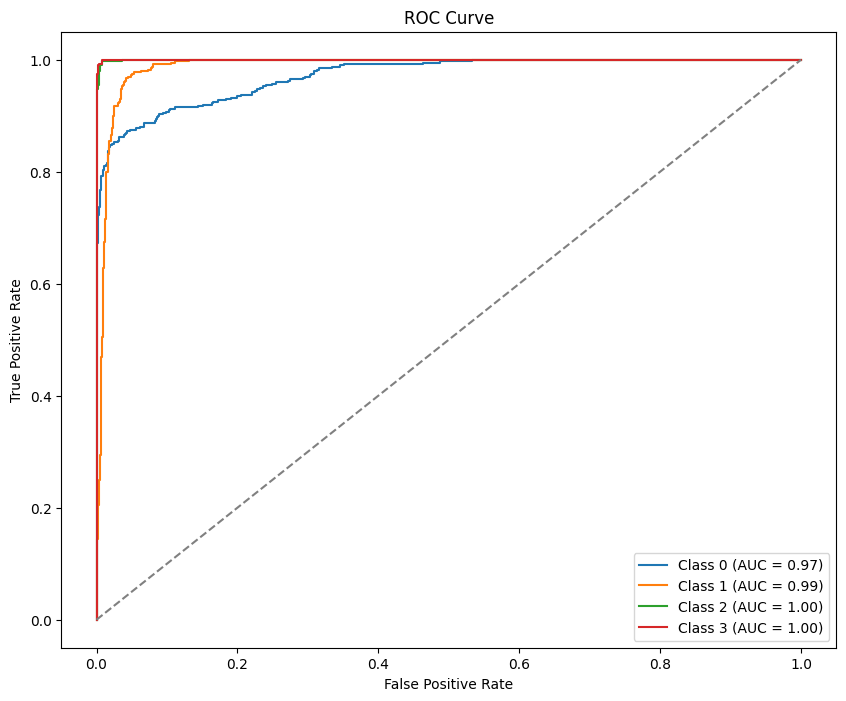

In [12]:
#4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_label_encoded, classes=np.arange(len(os.listdir(train_dir))))
y_pred_bin =y_pred  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i],y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Fine Tuning the Base model and Training Again

In [28]:

from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [32]:
# model training

for layer in base_model.layers:
    layer.trainable = True

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 20
class_weights = {
    0: 1.8, #stronger push for good results
    1: 1.2, # penality for over dominance
    2: 1.0,
    3: 1.0
}

# Train the model
history_fine = model.fit(datagen(train_paths, train_labels, batch_size=batch_size),
                    steps_per_epoch=steps,
                    epochs=epochs,
                    callbacks=[lr_scheduler,early_stop],
                         class_weight=class_weights)

Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 143s 130ms/step - loss: 0.3518 - sparse_categorical_accuracy: 0.8875 - learning_rate: 5.0000e-04
Epoch 2/20
  1/280 ━━━━━━━━━━━━━━━━━━━━ 30s 110ms/step - loss: 0.0772 - sparse_categorical_accuracy: 0.9500

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy,learning_rate
  current = self.get_monitor_value(logs)


280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 127ms/step - loss: 0.2169 - sparse_categorical_accuracy: 0.9284 - learning_rate: 5.0000e-04
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 36s 127ms/step - loss: 0.1818 - sparse_categorical_accuracy: 0.9425 - learning_rate: 5.0000e-04
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - loss: 0.1329 - sparse_categorical_accuracy: 0.9577 - learning_rate: 5.0000e-04
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.1294 - sparse_categorical_accuracy: 0.9620 - learning_rate: 5.0000e-04
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 125ms/step - loss: 0.0993 - sparse_categorical_accuracy: 0.9682 - learning_rate: 5.0000e-04
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 125ms/step - loss: 0.1105 - sparse_categorical_accuracy: 0.9652 - learning_rate: 5.0000e-04
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - loss: 0.0819 - sparse_categorical_accuracy: 0.9755 - learning_rate: 5.0000e-04
Epoch 9/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 125ms/step - lo

<function matplotlib.pyplot.show(close=None, block=None)>

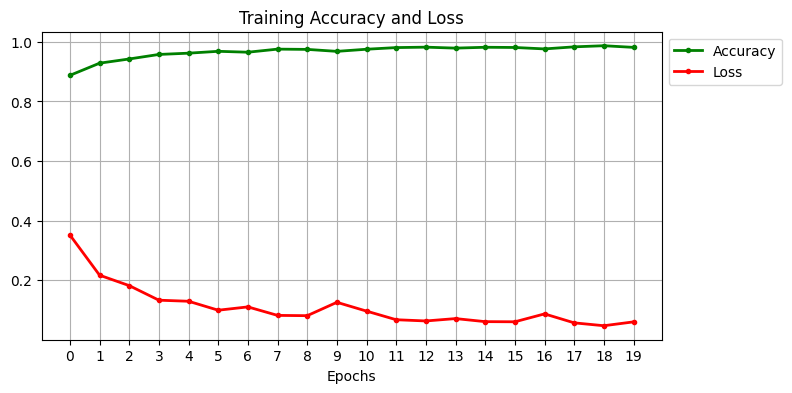

In [33]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history_fine.history['sparse_categorical_accuracy'],'.g-',linewidth=2, label='Training Accuracy')
plt.plot(history_fine.history['loss'],'.r-', linewidth=2)
plt.title('Training Accuracy and Loss')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy','Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show

In [34]:
test_images = open_images(test_paths)
test_label_encoded = encode_label(test_labels)

y_pred = model.predict(test_images)

print('Classification Report:')
print(classification_report(test_label_encoded, np.argmax(y_pred, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91       400
           1       0.91      0.98      0.94       400
           2       0.94      1.00      0.97       400
           3       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



[[335  38  22   5]
 [  3 392   3   2]
 [  0   0 400   0]
 [  0   1   0 399]]


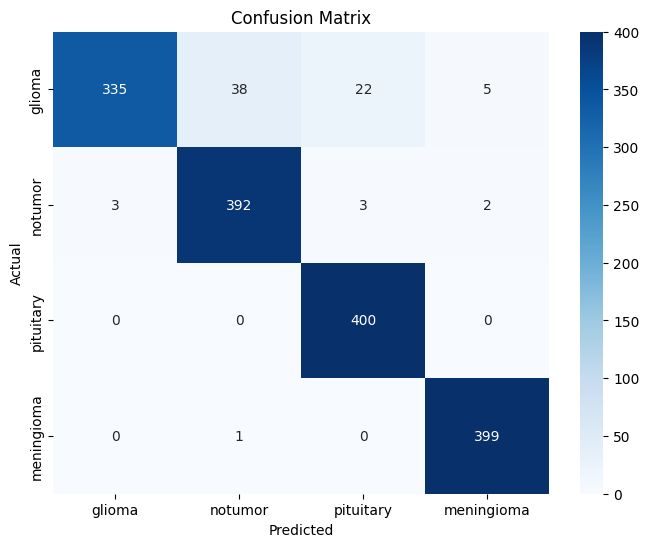

In [45]:
conf_matrix = confusion_matrix(test_label_encoded, np.argmax(y_pred, axis=1))
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Saving the model

In [39]:
model.save('BT_EfB0_model.keras')


### Loading the model

In [40]:
from keras.models import load_model
bt_model = load_model('BT_EfB0_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
[[1.6931369e-07 1.2902192e-04 5.5657893e-07 9.9987030e-01]]
Predicted class index: 3
Predicted tumor name: pitutary
Confidence : 0.9999


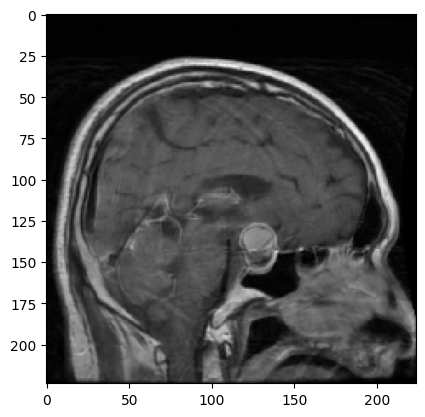

In [44]:
test_img = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/pituitary/Te-pi_20.jpg'
img = load_img(test_img, target_size=(224,224))
img = np.array(img)
img = preprocess_input(img)
img = np.expand_dims(img, axis=0)
pred = bt_model.predict(img)
print(pred)
predicted_class_index = np.argmax(pred)
class_labels = ['glioma', 'meningioma', 'notumor', 'pitutary']
print(f"Predicted class index: {predicted_class_index}")
print(f"Predicted tumor name: {class_labels[predicted_class_index]}")
print(f"Confidence : {pred[0][predicted_class_index]:.4f}")
plt.imshow(img[0])

## Implementing Explainable AI

---



In [18]:
!pip install opencv-python-headless

In [19]:
for i, layer in enumerate(bt_model.layers):
    print(i, type(layer).__name__, layer.name,
          f"→ output: {layer.output_shape}" if hasattr(layer, 'output_shape') else "")

0 InputLayer input_layer 
1 Rescaling rescaling 
2 Normalization normalization 
3 Rescaling rescaling_1 
4 ZeroPadding2D stem_conv_pad 
5 Conv2D stem_conv 
6 BatchNormalization stem_bn 
7 Activation stem_activation 
8 DepthwiseConv2D block1a_dwconv 
9 BatchNormalization block1a_bn 
10 Activation block1a_activation 
11 GlobalAveragePooling2D block1a_se_squeeze 
12 Reshape block1a_se_reshape 
13 Conv2D block1a_se_reduce 
14 Conv2D block1a_se_expand 
15 Multiply block1a_se_excite 
16 Conv2D block1a_project_conv 
17 BatchNormalization block1a_project_bn 
18 Conv2D block2a_expand_conv 
19 BatchNormalization block2a_expand_bn 
20 Activation block2a_expand_activation 
21 ZeroPadding2D block2a_dwconv_pad 
22 DepthwiseConv2D block2a_dwconv 
23 BatchNormalization block2a_bn 
24 Activation block2a_activation 
25 GlobalAveragePooling2D block2a_se_squeeze 
26 Reshape block2a_se_reshape 
27 Conv2D block2a_se_reduce 
28 Conv2D block2a_se_expand 
29 Multiply block2a_se_excite 
30 Conv2D block2a_projec

In [20]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from keras.preprocessing.image import load_img, img_to_array

IMAGE_SIZE = 128
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']


def _get_conv_extractor(model):
    """Returns a Functional model: VGG16 input → block5_conv3 output only."""
    vgg16     = model.get_layer('vgg16')
    last_conv = vgg16.get_layer('block5_conv3')
    return tf.keras.Model(inputs=vgg16.input, outputs=last_conv.output), vgg16


# ─── EigenCAM ─────────────────────────────────────────────────────────────────
def compute_eigencam(model, img_array):
    img_tensor = tf.cast(img_array, tf.float32)

    # ✅ Use model() directly for predictions
    preds      = model(img_tensor, training=False)
    class_idx  = int(tf.argmax(preds[0]).numpy())
    confidence = float(tf.reduce_max(preds).numpy())

    extractor, _ = _get_conv_extractor(model)
    conv_out      = extractor(img_tensor)             # (1, 14, 14, 512)

    acts     = conv_out[0].numpy()                    # (14, 14, 512)
    h, w, c  = acts.shape
    reshaped = acts.reshape(h * w, c)
    reshaped -= reshaped.mean(axis=0)

    _, _, Vt        = np.linalg.svd(reshaped, full_matrices=False)
    heatmap         = reshaped @ Vt[0]                # (h*w,)
    heatmap         = heatmap.reshape(h, w)
    heatmap         = np.maximum(heatmap, 0)
    heatmap         = heatmap / (heatmap.max() + 1e-8)

    return heatmap, class_idx, confidence


# ─── Overlay ──────────────────────────────────────────────────────────────────
def overlay_heatmap(heatmap, original_img, alpha=0.45):
    h, w    = original_img.shape[:2]
    resized = cv2.resize(heatmap, (w, h))
    colored = cv2.applyColorMap(np.uint8(255 * resized), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(original_img, 1 - alpha, colored, alpha, 0)

In [23]:
def detect_and_display_xai(image_path, model, method='gradcam', alpha=0.45):
    """
    Args:
        image_path : str path to MRI image
        model      : trained Keras model (bt_model)
        method     : 'gradcam' or 'eigencam'
        alpha      : heatmap opacity (0.0–1.0)
    """
    try:
        img        = load_img(image_path, target_size=(224, 224))
        img_array  = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_input  = np.expand_dims(img_array, axis=0)   # (1, 224, 224, 3)
        orig_uint8 = img_array.astype(np.uint8)

        method = method.lower()

        if method == 'eigencam':
            heatmap, class_idx, confidence = compute_eigencam(model, img_input)
            method_label = 'EigenCAM'
        else:
            raise ValueError("method must be 'gradcam' or 'eigencam'")

        label       = class_labels[class_idx]
        result_text = 'No Tumor Detected' if label == 'notumor' else f'Tumor: {label.capitalize()}'
        superimposed = overlay_heatmap(heatmap, orig_uint8, alpha=alpha)

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(
            f'{method_label}  |  {result_text}  |  Confidence: {confidence*100:.1f}%',
            fontsize=13, fontweight='bold'
        )
        axes[0].imshow(orig_uint8);       axes[0].set_title('Original MRI');            axes[0].axis('off')
        axes[1].imshow(cv2.resize(heatmap, (IMAGE_SIZE, IMAGE_SIZE)), cmap='jet')
        axes[1].set_title(f'{method_label} Heatmap');  axes[1].axis('off')
        axes[2].imshow(superimposed);     axes[2].set_title('Overlay');                 axes[2].axis('off')

        sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
        plt.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04, label='Activation intensity')
        plt.tight_layout()
        plt.show()

        print(f"  Predicted : {label}  |  Confidence: {confidence*100:.2f}%  |  Method: {method_label}")

    except Exception as e:
        import traceback
        print(f'Error: {e}')
        traceback.print_exc()   # full traceback so errors are easier to debug

In [24]:
# ── Test a single image with both methods side by side ──
img_path = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/meningioma/Te-aug-me_69.jpg'

# Run EigenCAM on the same image
detect_and_display_xai(img_path, bt_model, method='eigencam')

Error: No such layer: vgg16. Existing layers are: ['input_layer', 'rescaling', 'normalization', 'rescaling_1', 'stem_conv_pad', 'stem_conv', 'stem_bn', 'stem_activation', 'block1a_dwconv', 'block1a_bn', 'block1a_activation', 'block1a_se_squeeze', 'block1a_se_reshape', 'block1a_se_reduce', 'block1a_se_expand', 'block1a_se_excite', 'block1a_project_conv', 'block1a_project_bn', 'block2a_expand_conv', 'block2a_expand_bn', 'block2a_expand_activation', 'block2a_dwconv_pad', 'block2a_dwconv', 'block2a_bn', 'block2a_activation', 'block2a_se_squeeze', 'block2a_se_reshape', 'block2a_se_reduce', 'block2a_se_expand', 'block2a_se_excite', 'block2a_project_conv', 'block2a_project_bn', 'block2b_expand_conv', 'block2b_expand_bn', 'block2b_expand_activation', 'block2b_dwconv', 'block2b_bn', 'block2b_activation', 'block2b_se_squeeze', 'block2b_se_reshape', 'block2b_se_reduce', 'block2b_se_expand', 'block2b_se_excite', 'block2b_project_conv', 'block2b_project_bn', 'block2b_drop', 'block2b_add', 'block3a_

Traceback (most recent call last):
  File "/tmp/ipykernel_4314/661383800.py", line 19, in detect_and_display_xai
    heatmap, class_idx, confidence = compute_eigencam(model, img_input)
                                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4314/1318782755.py", line 27, in compute_eigencam
    extractor, _ = _get_conv_extractor(model)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4314/1318782755.py", line 13, in _get_conv_extractor
    vgg16     = model.get_layer('vgg16')
                ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "/usr/local/lib/python3.12/dist-packages/keras/src/models/model.py", line 213, in get_layer
    raise ValueError(
ValueError: No such layer: vgg16. Existing layers are: ['input_layer', 'rescaling', 'normalization', 'rescaling_1', 'stem_conv_pad', 'ste